# Coca-Cola vs PepsiCo: A Financial Comparison

## 1. Introduction

This project compares the financial performance of Coca-Cola and PepsiCo from 2020 to 2025.  
The main objective is to evaluate which company shows stronger performance in terms of profitability and financial stability.  
The target users are business students and beginner investors who want to understand how financial ratios can be used to compare company performance.

## 2. Data Source

The dataset used in this project was retrieved from WRDS through the `comp.funda` table.  
The analysis focuses on two companies: Coca-Cola (`KO`) and PepsiCo (`PEP`).  
The sample period covers fiscal years 2020 to 2025.

The main variables used are:
- `fyear`: fiscal year
- `sale`: revenue
- `ni`: net income
- `at`: total assets
- `lt`: total liabilities
- `act`: current assets
- `lct`: current liabilities

These variables are used to calculate net profit margin, current ratio, and debt ratio.

## 3. Connect to WRDS

In this section, Python is connected to the WRDS platform using the `wrds` library.  
This connection allows the notebook to directly access financial data stored in WRDS databases.

A valid WRDS account is required to run this notebook.  
After the connection is established, the notebook can retrieve company-level accounting data for further analysis.

In [87]:
import wrds
import pandas as pd

db = wrds.Connection()

Enter your WRDS username [HUAWEI]: fzh123
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\HUAWEI\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 4. Retrieve Data Using SQL

The financial data used in this project is retrieved from the `comp.funda` table in WRDS.  
SQL queries are used to select the required variables and filter the observations by company ticker and fiscal year.

Two companies are examined in this project:
- Coca-Cola (`KO`)
- PepsiCo (`PEP`)

The selected variables include revenue, net income, total assets, total liabilities, current assets, and current liabilities.  
These variables provide the foundation for ratio calculation and financial comparison.

In [88]:
db.list_tables(library='comp')[:20]

['aco_amda',
 'aco_imda',
 'aco_indfnta',
 'aco_indfntq',
 'aco_indfntytd',
 'aco_indsta',
 'aco_indstq',
 'aco_indstytd',
 'aco_notesa',
 'aco_notesq',
 'aco_notessa',
 'aco_notesytd',
 'aco_pnfnda',
 'aco_pnfndq',
 'aco_pnfndytd',
 'aco_pnfnta',
 'aco_pnfntq',
 'aco_pnfntytd',
 'aco_transa',
 'aco_transq']

In [89]:
sql_query = """
SELECT fyear, sale, ni, at, lt, act, lct
FROM comp.funda
WHERE tic = 'KO'
AND fyear >= 2020
ORDER BY fyear
"""

ko_data = db.raw_sql(sql_query)
ko_data

,fyear,sale,ni,at,lt,act,lct
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>


In [94]:
sql_query = """
SELECT fyear, sale, ni, at, lt, act, lct
FROM comp.funda
WHERE tic = 'PEP'
AND fyear >= 2020
ORDER BY fyear
"""

pep_data = db.raw_sql(sql_query)
pep_data

,fyear,sale,ni,at,lt,act,lct
0,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0
1,2020,70372.0,7120.0,92918.0,<NA>,<NA>,<NA>
2,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0
3,2021,79474.0,7618.0,92377.0,<NA>,<NA>,<NA>
4,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0
5,2022,86392.0,8910.0,92187.0,<NA>,<NA>,<NA>
6,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0
7,2023,91471.0,9074.0,100495.0,<NA>,<NA>,<NA>
8,2024,91854.0,9578.0,99467.0,81296.0,25826.0,31536.0
9,2024,91854.0,9578.0,99467.0,<NA>,<NA>,<NA>


## 5. Data Cleaning and Ratio Calculation

After retrieving the raw data from WRDS, the two company datasets are combined into a single DataFrame.  
The data is then cleaned to remove duplicate or incomplete rows so that each company has only one observation for each fiscal year.

Three financial ratios are calculated for further analysis:

- **Net Profit Margin** = Net Income / Revenue  
- **Current Ratio** = Current Assets / Current Liabilities  
- **Debt Ratio** = Total Liabilities / Total Assets  

These ratios help evaluate profitability, liquidity, and financial stability.

In [95]:
ko_data["company"] = "Coca-Cola"
pep_data["company"] = "PepsiCo"

financial_data = pd.concat([ko_data, pep_data], ignore_index=True)
financial_data

,fyear,sale,ni,at,lt,act,lct,company
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>,Coca-Cola
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>,Coca-Cola
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>,Coca-Cola
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>,Coca-Cola
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>,Coca-Cola


In [96]:
financial_data["net_profit_margin"] = financial_data["ni"] / financial_data["sale"]
financial_data["current_ratio"] = financial_data["act"] / financial_data["lct"]
financial_data["debt_ratio"] = financial_data["lt"] / financial_data["at"]

financial_data

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>,Coca-Cola,0.234658,<NA>,<NA>
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>,Coca-Cola,0.252775,<NA>,<NA>
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>,Coca-Cola,0.221886,<NA>,<NA>
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>,Coca-Cola,0.234165,<NA>,<NA>
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>,Coca-Cola,0.225898,<NA>,<NA>


In [97]:
financial_data_clean = financial_data.dropna(subset=["lt", "act", "lct"]).copy()
financial_data_clean

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
10,2025,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,Coca-Cola,0.273399,1.458766,0.672998
12,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,PepsiCo,0.101177,0.984126,0.854151
14,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,PepsiCo,0.095855,0.830778,0.825162
16,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,PepsiCo,0.103135,0.804144,0.812631
18,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,PepsiCo,0.099201,0.851582,0.814548


In [98]:
financial_data_clean = financial_data_clean.sort_values(["company", "fyear"]).reset_index(drop=True)
financial_data_clean

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
1,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
2,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
3,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
4,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
5,2025,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,Coca-Cola,0.273399,1.458766,0.672998
6,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,PepsiCo,0.101177,0.984126,0.854151
7,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,PepsiCo,0.095855,0.830778,0.825162
8,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,PepsiCo,0.103135,0.804144,0.812631
9,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,PepsiCo,0.099201,0.851582,0.814548


## 5.1 Reusable Comparison Function

In [99]:
def get_company_financial_data(db, ticker1, ticker2, start_year=2020):
    query = f"""
    SELECT fyear, tic, sale, ni, at, lt, act, lct
    FROM comp.funda
    WHERE tic IN ('{ticker1}', '{ticker2}')
      AND fyear >= {start_year}
    ORDER BY tic, fyear
    """
    
    data = db.raw_sql(query)
    
    ticker_map = {
        ticker1: ticker1,
        ticker2: ticker2
    }
    
    # optional rename for your current project
    if ticker1 == "KO":
        ticker_map[ticker1] = "Coca-Cola"
    if ticker2 == "PEP":
        ticker_map[ticker2] = "PepsiCo"
    
    data["company"] = data["tic"].map(ticker_map)
    
    data["net_profit_margin"] = data["ni"] / data["sale"]
    data["current_ratio"] = data["act"] / data["lct"]
    data["debt_ratio"] = data["lt"] / data["at"]
    
    data_clean = data.dropna(subset=["lt", "act", "lct"]).copy()
    data_clean = data_clean.sort_values(["company", "fyear"]).reset_index(drop=True)
    
    return data_clean

In [100]:
financial_data_clean = get_company_financial_data(db, "KO", "PEP", 2020)
financial_data_clean

,fyear,tic,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,KO,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
1,2021,KO,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
2,2022,KO,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
3,2023,KO,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
4,2024,KO,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
5,2025,KO,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,Coca-Cola,0.273399,1.458766,0.672998
6,2020,PEP,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,PepsiCo,0.101177,0.984126,0.854151
7,2021,PEP,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,PepsiCo,0.095855,0.830778,0.825162
8,2022,PEP,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,PepsiCo,0.103135,0.804144,0.812631
9,2023,PEP,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,PepsiCo,0.099201,0.851582,0.814548


## 5.2 Industry Benchmark Preparation

In [101]:
industry_info_query = """
SELECT DISTINCT a.tic, a.gvkey, b.sic
FROM comp.funda AS a
JOIN comp.company AS b
ON a.gvkey = b.gvkey
WHERE a.tic IN ('KO', 'PEP')
ORDER BY a.tic
"""

industry_info = db.raw_sql(industry_info_query)
industry_info

,tic,gvkey,sic
0,KO,003144,2086
1,PEP,008479,2080


In [102]:
industry_info["sic2"] = industry_info["sic"].astype(str).str[:2]
industry_info

,tic,gvkey,sic,sic2
0,KO,003144,2086,20
1,PEP,008479,2080,20


In [103]:
industry_code = industry_info["sic2"].iloc[0]
industry_code

'20'

In [104]:
industry_query = f"""
SELECT a.fyear, a.tic, a.sale, a.ni, a.at, a.lt, a.act, a.lct, b.sic
FROM comp.funda AS a
JOIN comp.company AS b
ON a.gvkey = b.gvkey
WHERE a.fyear >= 2020
  AND SUBSTR(CAST(b.sic AS TEXT), 1, 2) = '{industry_code}'
ORDER BY a.fyear, a.tic
"""

industry_data = db.raw_sql(industry_query)
industry_data.head()

,fyear,tic,sale,ni,at,lt,act,lct,sic
0,2020,0270B,13948.939,264.936,9186.036,6225.304,6176.55,4757.995,2000
1,2020,0270B,13948.939,264.936,9186.036,<NA>,<NA>,<NA>,2000
2,2020,5168B,2.576,-0.146,0.994,<NA>,<NA>,<NA>,2060
3,2020,5168B,2.576,-0.146,0.994,0.597,0.519,0.229,2060
4,2020,6179B,1911.137,-136.506,3282.822,<NA>,<NA>,<NA>,2015


In [105]:
industry_data["net_profit_margin"] = industry_data["ni"] / industry_data["sale"]
industry_data["current_ratio"] = industry_data["act"] / industry_data["lct"]
industry_data["debt_ratio"] = industry_data["lt"] / industry_data["at"]
industry_data["roa"] = industry_data["ni"] / industry_data["at"]
industry_data.head()

,fyear,tic,sale,ni,at,lt,act,lct,sic,net_profit_margin,current_ratio,debt_ratio,roa
0,2020,0270B,13948.939,264.936,9186.036,6225.304,6176.55,4757.995,2000,0.018993,1.298141,0.677692,0.028841
1,2020,0270B,13948.939,264.936,9186.036,<NA>,<NA>,<NA>,2000,0.018993,<NA>,<NA>,0.028841
2,2020,5168B,2.576,-0.146,0.994,<NA>,<NA>,<NA>,2060,-0.056677,<NA>,<NA>,-0.146881
3,2020,5168B,2.576,-0.146,0.994,0.597,0.519,0.229,2060,-0.056677,2.266376,0.600604,-0.146881
4,2020,6179B,1911.137,-136.506,3282.822,<NA>,<NA>,<NA>,2015,-0.071427,<NA>,<NA>,-0.041582


In [106]:
import numpy as np

industry_data = industry_data.replace([np.inf, -np.inf], np.nan)

industry_data_clean = industry_data.dropna(
    subset=["net_profit_margin", "current_ratio", "debt_ratio", "roa"]
).copy()

industry_data_clean = industry_data_clean[
    (industry_data_clean["net_profit_margin"] > -1) & (industry_data_clean["net_profit_margin"] < 1) &
    (industry_data_clean["current_ratio"] >= 0) & (industry_data_clean["current_ratio"] < 10) &
    (industry_data_clean["debt_ratio"] >= 0) & (industry_data_clean["debt_ratio"] < 5) &
    (industry_data_clean["roa"] > -1) & (industry_data_clean["roa"] < 1)
].copy()

industry_data_clean.head()

,fyear,tic,sale,ni,at,lt,act,lct,sic,net_profit_margin,current_ratio,debt_ratio,roa
0,2020,0270B,13948.939,264.936,9186.036,6225.304,6176.55,4757.995,2000,0.018993,1.298141,0.677692,0.028841
3,2020,5168B,2.576,-0.146,0.994,0.597,0.519,0.229,2060,-0.056677,2.266376,0.600604,-0.146881
5,2020,6179B,1911.137,-136.506,3282.822,2028.619,1174.348,374.912,2015,-0.071427,3.13233,0.61795,-0.041582
6,2020,ABEV,11103.587,2164.343,23812.123,9518.493,6722.045,6367.421,2082,0.194923,1.055694,0.399733,0.090892
8,2020,ADM,64355.0,1772.0,49719.0,29623.0,27286.0,18182.0,2070,0.027535,1.500715,0.595808,0.03564


In [107]:
industry_avg = industry_data_clean.groupby("fyear")[
    ["net_profit_margin", "current_ratio", "debt_ratio", "roa"]
].mean().reset_index()

industry_avg["company"] = "Industry Average"
industry_avg

,fyear,net_profit_margin,current_ratio,debt_ratio,roa,company
0,2020,0.01947,2.297104,0.53767,0.009165,Industry Average
1,2021,0.009063,2.13546,0.547913,0.015677,Industry Average
2,2022,-0.021557,2.151947,0.562983,-0.016703,Industry Average
3,2023,-0.023943,2.136432,0.575938,-0.013322,Industry Average
4,2024,-0.01933,1.997777,0.582564,-0.00688,Industry Average
5,2025,0.022519,1.926222,0.570554,0.020891,Industry Average


In [108]:
financial_data_clean["roa"] = financial_data_clean["ni"] / financial_data_clean["at"]
financial_data_clean.head()

,fyear,tic,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio,roa
0,2020,KO,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186,0.088744
1,2021,KO,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524,0.103557
2,2022,KO,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592,0.102864
3,2023,KO,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739,0.109659
4,2024,KO,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772,0.10573


In [109]:
comparison_with_industry = pd.concat([
    financial_data_clean[["fyear", "company", "net_profit_margin", "current_ratio", "debt_ratio", "roa"]],
    industry_avg[["fyear", "company", "net_profit_margin", "current_ratio", "debt_ratio", "roa"]]
], ignore_index=True)

comparison_with_industry

,fyear,company,net_profit_margin,current_ratio,debt_ratio,roa
0,2020,Coca-Cola,0.234658,1.317718,0.756186,0.088744
1,2021,Coca-Cola,0.252775,1.130075,0.736524,0.103557
2,2022,Coca-Cola,0.221886,1.145356,0.721592,0.102864
3,2023,Coca-Cola,0.234165,1.134105,0.718739,0.109659
4,2024,Coca-Cola,0.225898,1.029625,0.73772,0.10573
5,2025,Coca-Cola,0.273399,1.458766,0.672998,0.125048
6,2020,PepsiCo,0.101177,0.984126,0.854151,0.076627
7,2021,PepsiCo,0.095855,0.830778,0.825162,0.082466
8,2022,PepsiCo,0.103135,0.804144,0.812631,0.096651
9,2023,PepsiCo,0.099201,0.851582,0.814548,0.090293


## 6. Revenue Comparison

In [110]:
import os
os.makedirs("figures", exist_ok=True)

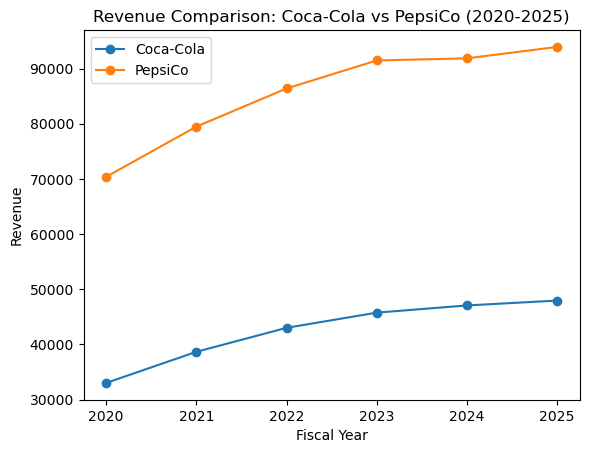

In [111]:
import matplotlib.pyplot as plt

for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["sale"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Revenue")
plt.title("Revenue Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/revenue_comparison.png", bbox_inches="tight")
plt.show()

The chart shows that PepsiCo consistently generated higher revenue than Coca-Cola from 2020 to 2025.  
Both companies also experienced an overall upward trend in revenue during the sample period, suggesting business growth.

This indicates that PepsiCo operates at a larger business scale.  
However, higher revenue alone does not necessarily mean stronger overall financial performance, so further analysis is needed to evaluate profitability and financial stability.

### 7. Net Income Comparison


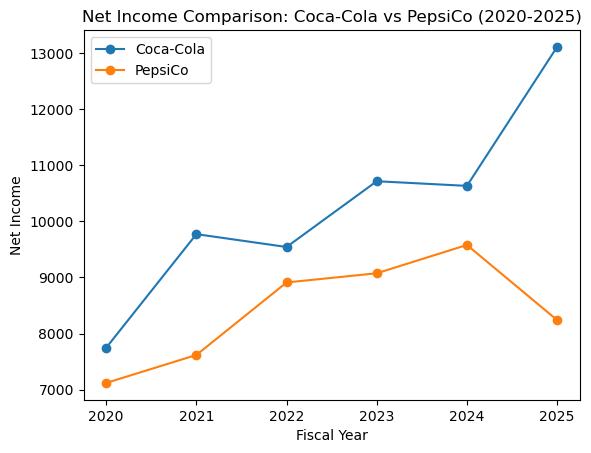

In [112]:
for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["ni"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Net Income")
plt.title("Net Income Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/net_income_analysis.png", bbox_inches="tight")
plt.show()

Both Coca-Cola and PepsiCo reported solid net income during the period.  
Although PepsiCo generated much higher revenue, Coca-Cola maintained relatively strong net income performance.

This suggests that Coca-Cola may have been more efficient in converting sales into profit.  
Therefore, comparing net income together with revenue is important, because larger sales do not automatically lead to stronger profit performance.

## 8. Profitability Analysis with Industry Benchmark

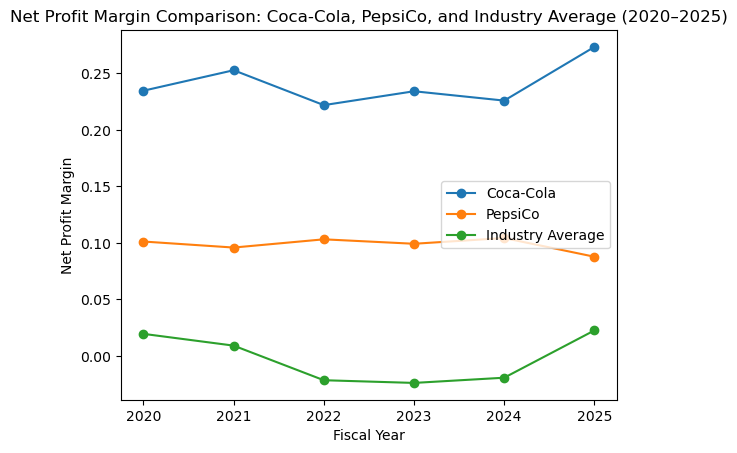

In [113]:
import matplotlib.pyplot as plt

for company in comparison_with_industry["company"].unique():
    company_data = comparison_with_industry[comparison_with_industry["company"] == company]
    plt.plot(
        company_data["fyear"],
        company_data["net_profit_margin"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("Net Profit Margin")
plt.title("Net Profit Margin Comparison: Coca-Cola, PepsiCo, and Industry Average (2020–2025)")
plt.legend()
plt.savefig("figures/net_profit_margin_with_industry.png", bbox_inches="tight")
plt.show()

Coca-Cola shows a consistently higher net profit margin than PepsiCo and remains above the industry average in most years.  
This suggests that Coca-Cola performs more strongly not only relative to PepsiCo, but also relative to the broader industry benchmark.

From a profitability perspective, Coca-Cola appears to be more efficient in converting revenue into profit.  
This also shows that a company with lower revenue can still outperform both a direct competitor and the industry average in profitability.

## 8.1 ROA Analysis with Industry Benchmark

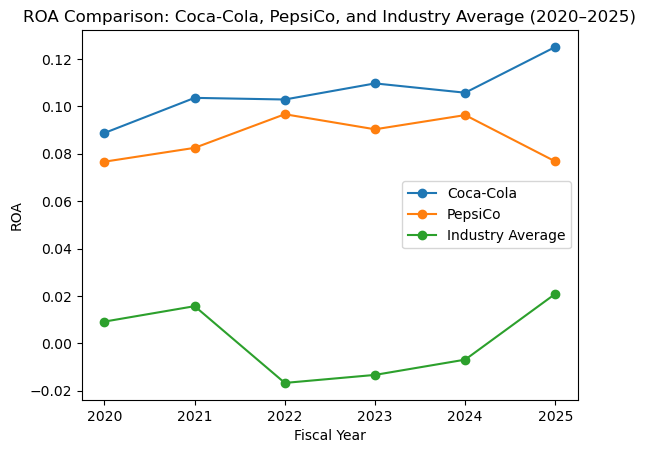

In [114]:
import matplotlib.pyplot as plt

for company in comparison_with_industry["company"].unique():
    company_data = comparison_with_industry[comparison_with_industry["company"] == company]
    plt.plot(
        company_data["fyear"],
        company_data["roa"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("ROA")
plt.title("ROA Comparison: Coca-Cola, PepsiCo, and Industry Average (2020–2025)")
plt.legend()
plt.savefig("figures/roa_with_industry.png", bbox_inches="tight")
plt.show()

Coca-Cola reports a consistently higher return on assets than PepsiCo and remains above the industry average in most years.  
This suggests that Coca-Cola uses its asset base more efficiently to generate profit.

From an asset-efficiency perspective, Coca-Cola appears stronger than both its direct competitor and the broader industry benchmark.  
This supports the earlier profitability findings and strengthens the conclusion that Coca-Cola performs better in ratio-based measures.

## 9. Liquidity Analysis with Industry Benchmark

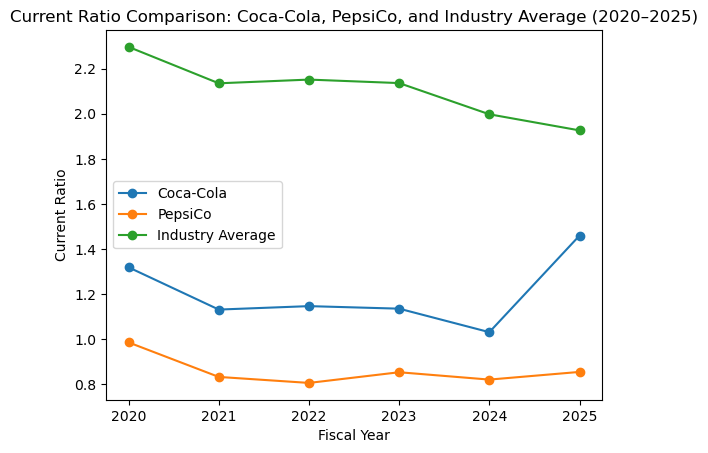

In [115]:
for company in comparison_with_industry["company"].unique():
    company_data = comparison_with_industry[comparison_with_industry["company"] == company]
    plt.plot(
        company_data["fyear"],
        company_data["current_ratio"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("Current Ratio")
plt.title("Current Ratio Comparison: Coca-Cola, PepsiCo, and Industry Average (2020–2025)")
plt.legend()
plt.savefig("figures/current_ratio_with_industry.png", bbox_inches="tight")
plt.show()

Coca-Cola generally reports a higher current ratio than PepsiCo and is also below the industry average, while PepsiCo remains even further below the benchmark.  
This suggests that Coca-Cola has a relatively stronger short-term liquidity position than its direct competitor, although both companies are more conservative than the broader industry average.

In other words, Coca-Cola appears better able to cover its current liabilities with its current assets than PepsiCo.  
This strengthens the conclusion that Coca-Cola is financially more stable in the short term.

## 10. Debt Ratio Analysis with Industry Benchmark

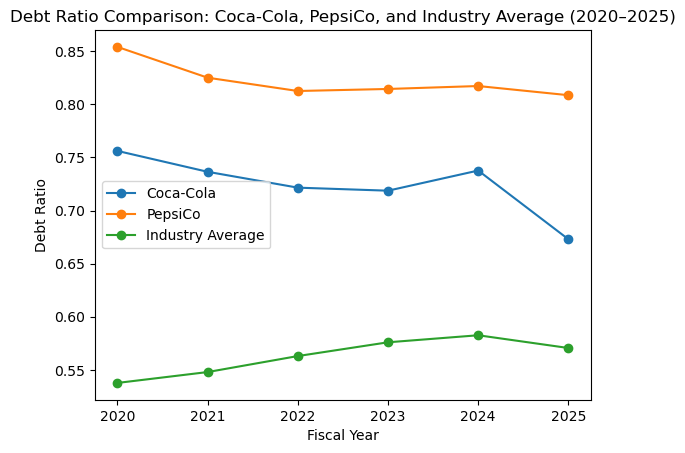

In [116]:
for company in comparison_with_industry["company"].unique():
    company_data = comparison_with_industry[comparison_with_industry["company"] == company]
    plt.plot(
        company_data["fyear"],
        company_data["debt_ratio"],
        marker="o",
        label=company
    )

plt.xlabel("Fiscal Year")
plt.ylabel("Debt Ratio")
plt.title("Debt Ratio Comparison: Coca-Cola, PepsiCo, and Industry Average (2020–2025)")
plt.legend()
plt.savefig("figures/debt_ratio_with_industry.png", bbox_inches="tight")
plt.show()

Both Coca-Cola and PepsiCo report higher debt ratios than the industry average, and PepsiCo remains higher than Coca-Cola in most years.  
This suggests that PepsiCo relies more heavily on liabilities relative to both its direct peer and the broader industry benchmark.

By comparison, Coca-Cola appears to have a more conservative capital structure than PepsiCo, although both companies are more leveraged than the average firm in the industry group.  
This makes Coca-Cola appear relatively more stable from a balance-sheet perspective.

## 11. Overall Interpretation

The comparison between Coca-Cola and PepsiCo shows that the two companies have different financial strengths.  
PepsiCo generated consistently higher revenue from 2020 to 2025, which suggests that it operates at a larger business scale.

However, Coca-Cola performed better than PepsiCo in several ratio-based measures.  
It reported a higher net profit margin in most years, a stronger current ratio than PepsiCo, and a lower debt ratio across the sample period.

The industry benchmark adds an important perspective to this comparison.  
Coca-Cola’s profitability remained above the industry average in most years, while both Coca-Cola and PepsiCo showed lower liquidity and higher leverage than the industry benchmark.  
This suggests that PepsiCo is stronger in size, while Coca-Cola appears stronger in profitability and relatively stronger in financial stability compared with PepsiCo.

## 12. Conclusion

This project compares the financial performance of Coca-Cola and PepsiCo from 2020 to 2025 using WRDS data.

The analysis shows that PepsiCo generated higher revenue throughout the sample period, indicating a larger business scale.  
However, Coca-Cola achieved a higher net profit margin, maintained a stronger current ratio than PepsiCo, and reported a lower debt ratio in most years.

When compared with the industry benchmark, Coca-Cola also performed more strongly in profitability, while both companies appeared to have lower liquidity and higher leverage than the broader industry average.  
Overall, PepsiCo appears stronger in scale, while Coca-Cola appears stronger in profitability and relatively stronger in financial stability.

## 13. Limitations

This project has several limitations.  
First, PepsiCo has a broader business structure than Coca-Cola, including major snack brands, so the two companies are not perfectly comparable.  
Second, the analysis focuses on a limited set of accounting variables and ratios, which cannot fully capture all aspects of company performance.  
Third, the study is descriptive and does not include forecasting or valuation analysis.  
In addition, the industry benchmark is based on a broad two-digit SIC industry grouping, so it may not fully capture all competitive differences within the market.